# UAH-DriveSet - RAW GPS Analysis

## Objective

This notebook explores the RAW_GPS sensor data collected during a driving session.

The notebook focuses on:

- Reading GPS data
- Understanding file structure
- Identifying available variables
- Inspecting sampling behaviour
- Visualizing GPS signals

No feature engineering or machine learning is performed.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
dataset_path="/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/raw/UAH-DRIVESET-v1"

driver="D1"

trip="20151110175712-16km-D1-NORMAL1-SECONDARY"

trip_path=os.path.join(
    dataset_path,
    driver,
    trip
)

gps_path=os.path.join(
    trip_path,
    "RAW_GPS.txt"
)

print(gps_path)

/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/raw/UAH-DRIVESET-v1/D1/20151110175712-16km-D1-NORMAL1-SECONDARY/RAW_GPS.txt


In [3]:
with open(gps_path,"r") as f:

    for i in range(10):
        print(f.readline())

7.85 65.2 40.512787 -3.404477 612.7 4 5 331.9 0 0 0 0 

8.83 64.5 40.512924 -3.404577 612.5 4 5 331.9 0 0 0 0 

9.82 63.6 40.513065 -3.404680 612.9 4 5 330.8 1.055 0 0 0 

10.80 62.2 40.513210 -3.404772 613.3 4 5 330.8 1.055 0 0 0 

11.80 60.9 40.513348 -3.404868 613.5 3 5 330.1 0.703 0 0 0 

12.82 61.2 40.513477 -3.404971 613.8 3 5 329.4 1.406 0 0 0 

13.81 61.7 40.513615 -3.405080 614.0 3 5 328.7 1.406 0 0 0 

14.84 64.3 40.513741 -3.405192 614.3 3 5 327.0 2.461 2 0 0 

15.82 66.8 40.513882 -3.405315 614.6 3 5 325.5 3.164 2 0 0 

16.83 68.9 40.514019 -3.405443 614.6 3 5 325.9 1.055 0 0 0 



In [4]:
gps_columns = [
    "timestamp",
    "speed",
    "latitude",
    "longitude",
    "altitude",
    "gps_quality",
    "satellites",
    "heading",
    "extra_1",
    "extra_2",
    "extra_3",
    "extra_4"
]

gps_df = pd.read_csv(
    gps_path,
    sep=r"\s+",
    header=None,
    names=gps_columns
)

gps_df.head()

,timestamp,speed,latitude,longitude,altitude,gps_quality,satellites,heading,extra_1,extra_2,extra_3,extra_4
0,7.85,65.2,40.512787,-3.404477,612.7,4,5,331.9,0.000,0,0,0
1,8.83,64.5,40.512924,-3.404577,612.5,4,5,331.9,0.000,0,0,0
2,9.82,63.6,40.513065,-3.404680,612.9,4,5,330.8,1.055,0,0,0
3,10.80,62.2,40.513210,-3.404772,613.3,4,5,330.8,1.055,0,0,0
4,11.80,60.9,40.513348,-3.404868,613.5,3,5,330.1,0.703,0,0,0


In [5]:
print("Shape:", gps_df.shape)

print("\nMissing Values:")
print(gps_df.isnull().sum())

print("\nData Types:")
print(gps_df.dtypes)

gps_df.describe().T

Shape: (624, 12)

Missing Values:
timestamp      0
speed          0
latitude       0
longitude      0
altitude       0
gps_quality    0
satellites     0
heading        0
extra_1        0
extra_2        0
extra_3        0
extra_4        0
dtype: int64

Data Types:
timestamp      float64
speed          float64
latitude       float64
longitude      float64
altitude       float64
gps_quality      int64
satellites       int64
heading        float64
extra_1        float64
extra_2          int64
extra_3          int64
extra_4          int64
dtype: object


,count,mean,std,min,25%,50%,75%,max
timestamp,624.0,319.330176,180.278053,7.850000,163.550000,319.335000,475.052500,630.830000
speed,624.0,96.231891,9.573473,60.900000,89.700000,95.400000,104.325000,116.800000
latitude,624.0,40.547610,0.019292,40.512787,40.533779,40.547302,40.559782,40.584435
longitude,624.0,-3.476632,0.043260,-3.553698,-3.515802,-3.474110,-3.438148,-3.404477
altitude,624.0,660.167147,36.886306,609.000000,628.600000,654.250000,680.875000,736.000000
gps_quality,624.0,5.844551,0.913534,3.000000,6.000000,6.000000,6.000000,8.000000
satellites,624.0,5.000000,0.000000,5.000000,5.000000,5.000000,5.000000,5.000000
heading,624.0,302.471635,26.762911,242.200000,278.400000,301.450000,324.800000,354.700000
extra_1,624.0,2.346029,1.760792,0.000000,0.703000,2.109000,3.516000,10.195000
extra_2,624.0,0.363782,0.631467,0.000000,0.000000,0.000000,1.000000,2.000000


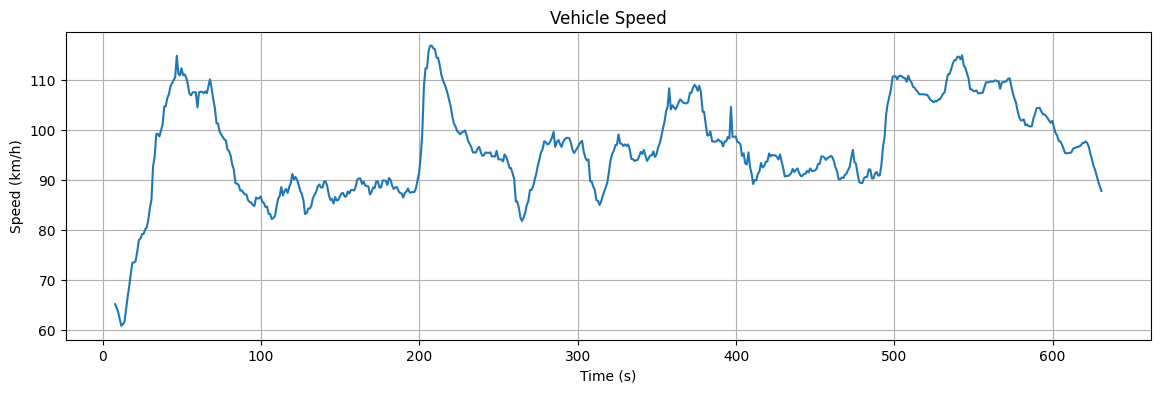

In [6]:
plt.figure(figsize=(14,4))

plt.plot(gps_df["timestamp"], gps_df["speed"])

plt.title("Vehicle Speed")

plt.xlabel("Time (s)")
plt.ylabel("Speed (km/h)")

plt.grid(True)

plt.show()

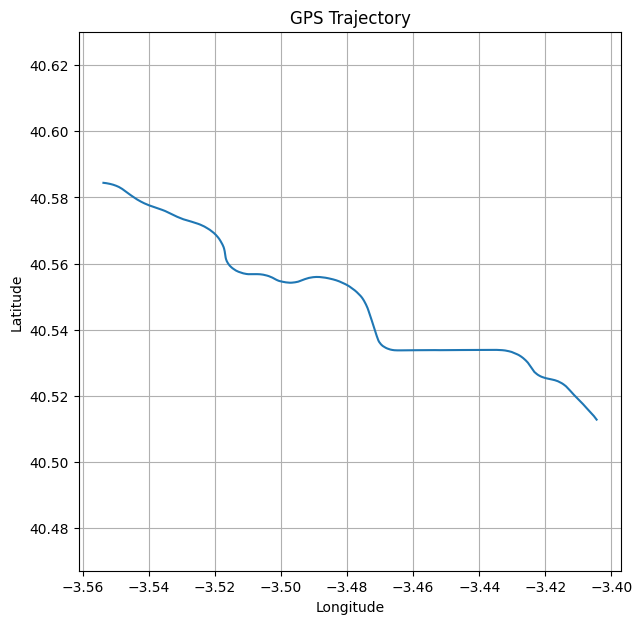

In [7]:
plt.figure(figsize=(7,7))

plt.plot(
    gps_df["longitude"],
    gps_df["latitude"]
)

plt.title("GPS Trajectory")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.axis("equal")

plt.grid(True)

plt.show()

In [8]:
time_diff = gps_df["timestamp"].diff()

print("Average Interval:", time_diff.mean())

print("Estimated Sampling Rate:", 1 / time_diff.mean())

Average Interval: 0.9999678972712681
Estimated Sampling Rate: 1.0000321037593503
